In [1]:
import pandas as pd
import obspy
import numpy as np
import matplotlib.pyplot as plt
from obspy import UTCDateTime
import os

import random
import json
Dtmin_Noise=-25
Dtmax_Noise=-5
Dtmin_Pn=-5.
Dtmax_Pn=10.
Dtmin_Sn=-5.
Dtmax_Sn=10.

vLg_max=3.5
vLg_min=3.1
vLg=0.5*(vLg_max+vLg_min)
vPg_max=6.2
vPg_min=5.2
vPg=0.5*(vPg_max+vPg_min)
print(vPg)
#vPg=6.

tminCoda=300.
tmaxCoda=320.

5.7


In [3]:
from new_functions import *

2020-12-29T11:19:29.762000Z
Earthquake at 2020-12-29T11:29:05.687000Z with magnitude 4.5


Processing stations of ODC:  22%|██▏       | 40/184 [00:00<00:00, 387.82it/s]

no Pn  0.5023446075849015 list index out of range
no Sn  0.5023446075849015 list index out of range


Processing stations of ODC:  85%|████████▌ | 157/184 [00:02<00:00, 57.96it/s] 

no Pn  0.7306198929710234 list index out of range
no Sn  0.7306198929710234 list index out of range
no Pn  0.733500723425621 list index out of range
no Sn  0.733500723425621 list index out of range


...

Processing stations of IRIS:  88%|████████▊ | 158/180 [00:03<00:00, 29.28it/s]

no Pn  0.7306197101175912 list index out of range
no Sn  0.7306197101175912 list index out of range
no Pn  0.733500723425621 list index out of range
no Sn  0.733500723425621 list index out of range


Processing stations of IRIS:  92%|█████████▏| 165/180 [00:03<00:00, 24.53it/s]

no Pn  0.6744700263941782 list index out of range
no Sn  0.6744700263941782 list index out of range
no Sn  0.7881287867248925 list index out of range


Processing stations of ICGC: 100%|██████████| 24/24 [00:00<00:00, 287.93it/s]


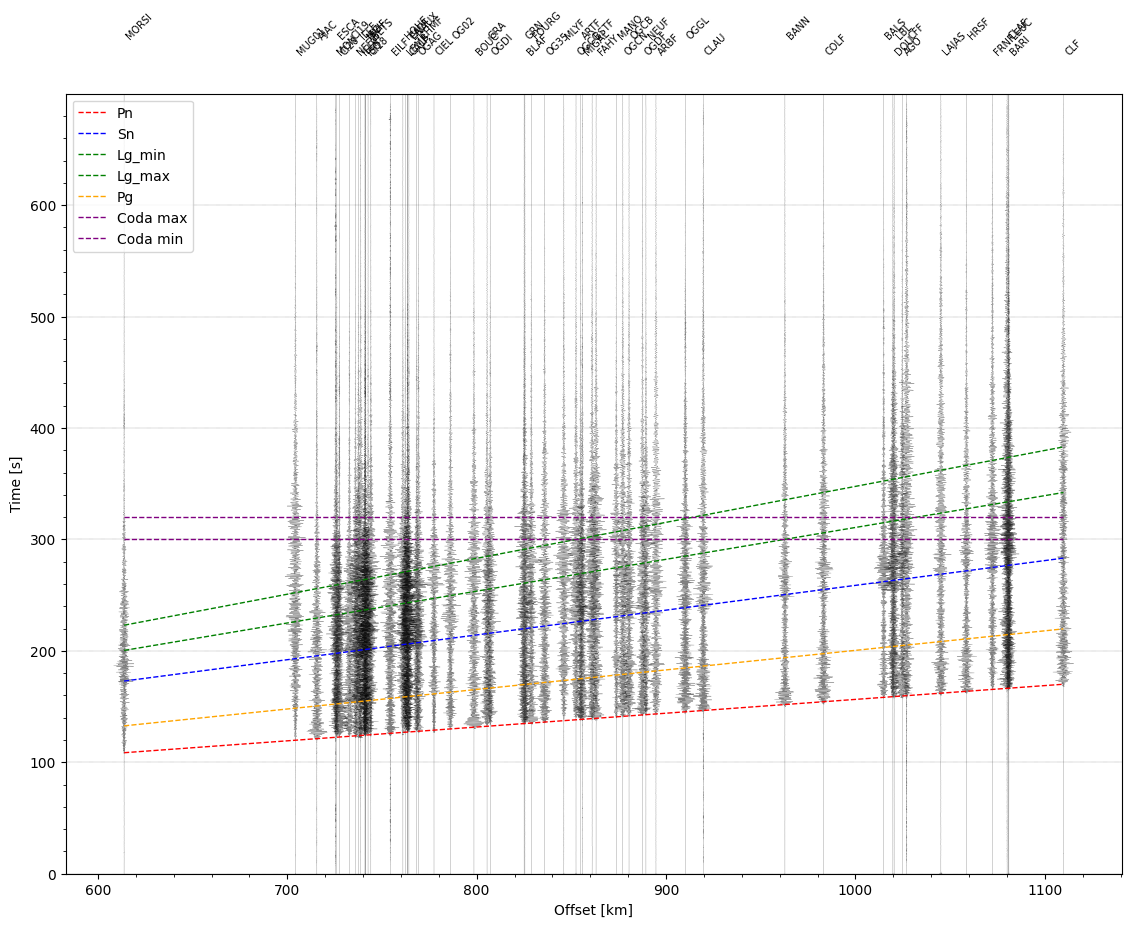

In [4]:
import warnings
warnings.filterwarnings("ignore")
datacenters =['RESIF','ODC','ETH','INGV','GEOFON', 'IRIS', 'ICGC']#,'BGR']
directory='/home/schreinl/Stage/Data1/'
distmin=0.5
distmax=10.
catalogue_4_5 = pd.read_csv('/home/schreinl/Stage/Data/bigger_than_4.5.csv')
catalogue_5 = pd.read_csv('/home/schreinl/Stage/Data/eq_4_france.csv')
catalogue_5 = pd.read_csv('/home/schreinl/Stage/Data/big_box_4.5.csv')
catalogue_5 = catalogue_5[catalogue_5['mag'] >= 4.0].reset_index(drop=True)

#catalogue_5 = pd.read_csv('/home/schreinl/Stage/Data/eq_4_france.csv')
#catalogue_5 = catalogue_5[catalogue_5['mag'] >= 4.0].reset_index(drop=True)
start = UTCDateTime(catalogue_5['time'][32]) -25
print(start)
end = start + 700
eq_lon = float(catalogue_5['longitude'][32])
eq_lat = float(catalogue_5['latitude'][32])
st_all, stations_all, plot = big_downloader2(datacenters, start, end, eq_lon, eq_lat, distmin, distmax, directory, plot=False)
time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")



st_plot_filt_all=st_all.copy()
fmin=1
fmax=5
st_plot_filt_all.filter("bandpass", freqmin=fmin, freqmax=fmax)


plot, st_Lg0 = plot_record_section(st_plot_filt_all[0:60], stations_all[0:60], eq_lat, 
eq_lon, start, tracehodo=True, v_Lg_min=vLg_min, v_Lg_max=vLg_max, 
v_Pg=vPg)


In [4]:
print(type(time_string))

<class 'str'>


In [5]:
import obspy
from scipy.fftpack import hilbert
from scipy.signal import savgol_filter

import numpy as np
#from obspy.signal.filter import envelope
from scipy.signal import resample


def envelope_calculator(data):
    hilb = hilbert(data)
    data = (data ** 2 + hilb ** 2) ** 0.5
    return data


st_envelope = obspy.Stream()
smallest = 7000
for tr in st_plot_filt_all:
    data_envelope = envelope_calculator(tr.data)
    npts = tr.stats.npts
    if npts >= smallest:
        samprate = tr.stats.sampling_rate
        t = np.arange(0, npts / samprate, 1 / samprate)
        tr_envelope = obspy.Trace(data=data_envelope, header=tr.stats)
        #data_resampled = resample(tr_envelope.data, 10000)
        #tr_resampled = obspy.Trace(data=data_resampled, header=tr.stats)
        st_envelope.append(tr_envelope)

257


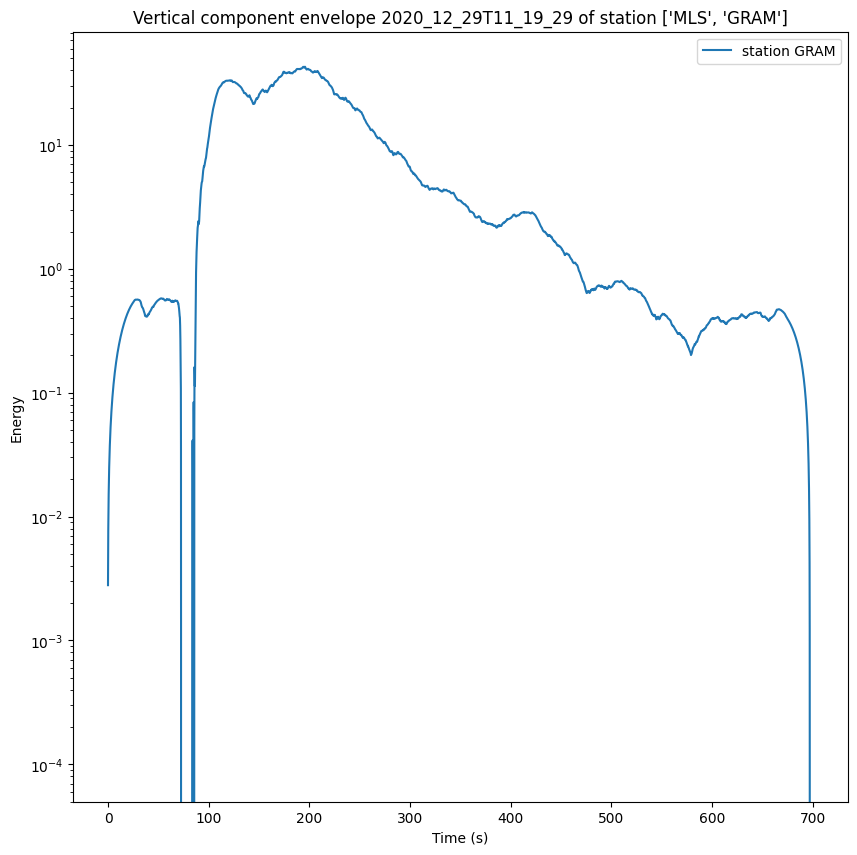

In [8]:
station = ["MLS","ECH"]
station = ['MLS', 'GRAM']
plt.figure(figsize=(10,10))
for i,tr in enumerate(st_envelope):
    if tr.stats.station == station[0] or tr.stats.station == station[1]:
        idx_reference = i
        print(i)
        npts = len(tr.data)
        samprate = tr.stats.sampling_rate #10000/700 
        t = np.arange(0, npts / samprate, 1 / samprate)

        #use a stable window length in s, while the window lenght in samples is dependant on the sample rate
        
        window_length = 50*samprate #min(2000, npts)
        if window_length % 2 == 0:
            window_length -= 1
        yhat = savgol_filter(tr.data, int(window_length), 3) 
        t = t[:len(yhat)]
        plt.title(f"Vertical component envelope {time_string} of station {station}")
        plt.ylabel("Energy")
        plt.xlabel("Time (s)")
        #plt.semilogy(t,st_envelope[i])
        plt.semilogy(t,yhat,label=f'station {tr.stats.station}')
        #plt.ylim([1e-9,1e-4])
        #plt.xlim([100,350])
        plt.legend()
plt.show()

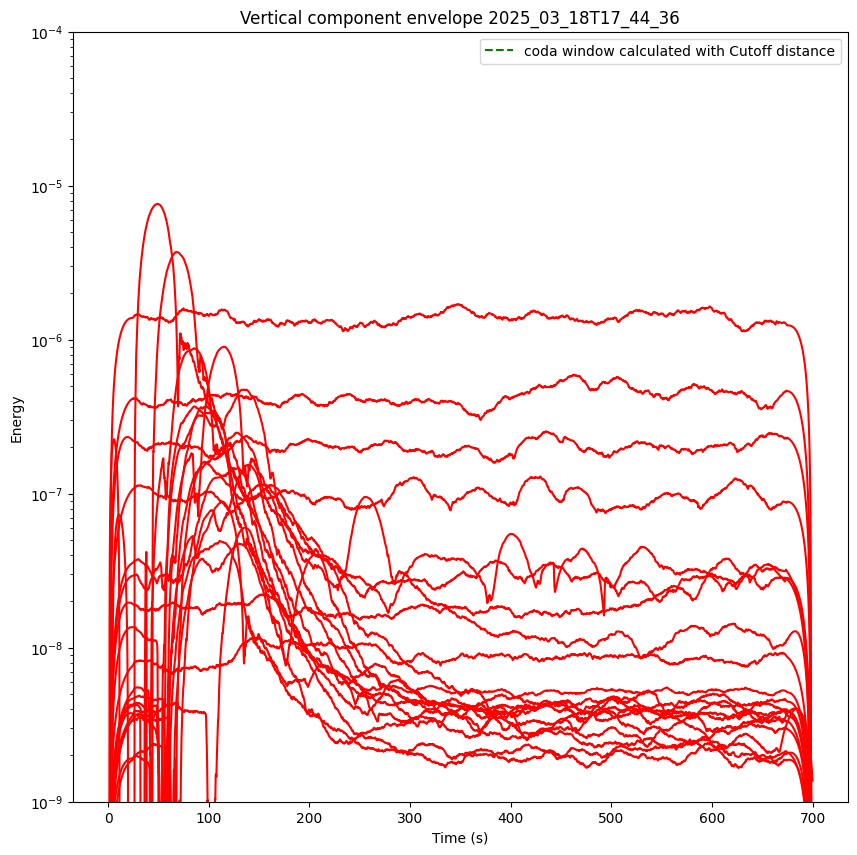

In [11]:
from scipy.signal import savgol_filter
from random import randint
def smooth_plot_envelope(time_string, n_traces,st_envelope, method='Cutoff distance',tmincoda_dist=None, tmaxcoda_dist=None,tmincoda_S = None, tmaxcoda_S= None,plotshow=False, savefig=True):
    testing = [(randint(1, len(st_plot_filt_all))) for i in range(n_traces)]

    plt.figure(figsize=(10,10))
    for i in testing:
        if i < len(st_envelope):
            npts = len(st_envelope[i].data)
            samprate = st_envelope[i].stats.sampling_rate #10000/700 
            t = np.arange(0, npts / samprate, 1 / samprate)

            #use a stable window length in s, while the window lenght in samples is dependant on the sample rate
            
            window_length = min(50*samprate, npts) # Ensure window_length is not greater than npts
            if window_length % 2 == 0:
                window_length -= 1
            yhat = savgol_filter(st_envelope[i].data, int(window_length), 3) 
            t = t[:len(yhat)]

            #plt.semilogy(t,st_envelope[i])
            plt.semilogy(t,yhat, color='red')
            plt.ylim([1e-9,1e-4])
            plt.title(f"Vertical component envelope {time_string}")
            plt.ylabel("Energy")
            plt.xlabel("Time (s)")
            #plt.xlim([100,350])
    plt.vlines(tmaxcoda_dist,ymax=1e-4,ymin=1e-9, label=f'coda window calculated with {method}',colors='g',linestyles='--')
    plt.vlines(tmincoda_dist,ymax=1e-4,ymin=1e-9,colors='g',linestyles='--')

    if tmincoda_S is not None and tmaxcoda_S is not None:
        plt.vlines(tmaxcoda_S,ymax=1e-4,ymin=1e-9, label='coda window calculated with S-wave',colors='b',linestyles='--')
        plt.vlines(tmincoda_S,ymax=1e-4,ymin=1e-9,colors='b',linestyles='--')
    #plt.vlines(350,ymax=1e-4,ymin=1e-9, label='coda window similar to Galina&Shapiro 2024',colors='b',linestyles='--')
    #plt.vlines(470,ymax=1e-4,ymin=1e-9,colors='b',linestyles='--')
    plt.legend()
    if savefig:
        mag_dir = '/home/schreinl/Stage/Data/Metadata/'
        with open(f"{mag_dir}{time_string}.txt", "r") as meta:
            for line in meta:
                if line.startswith("Magnitude:"):
                    magnitude = float(line.split(":")[1].strip())
        plt.savefig(f'/home/schreinl/Stage/Figures/SiteEffect/multiple_envelopes_{time_string}_{magnitude}_{method}_filtered.png', format='png')
    if plotshow:
        plt.show()
    
    return  
tset = smooth_plot_envelope(time_string, 50,st_envelope)

calculating SNR for Pn  phase
calculating SNR for Pg  phase
calculating SNR for Sn  phase
calculating SNR for Lg  phase
Reduced from   769  stations to   510  stations due to insufficient SNR or distance >  739.2799373563735
coda window set from 271.0693103640036-371.0693103640036s based on Lg cutoff distance
plotting Lg_Coda amplitudes


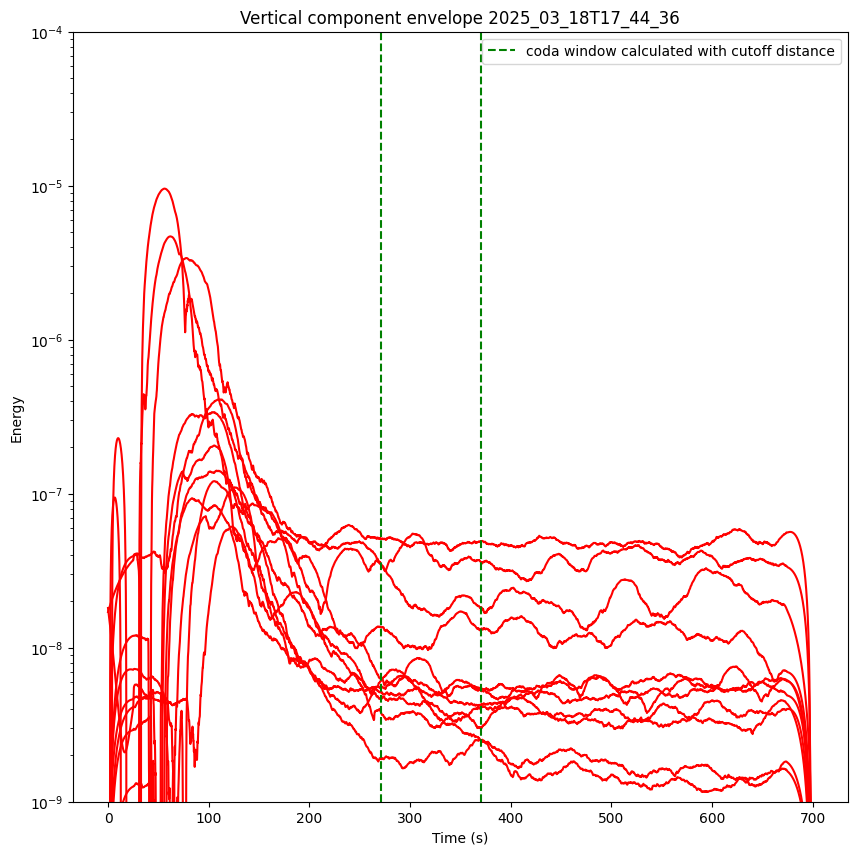

In [12]:
snr_threshold = 3.5
eq_start = start
stationref = "ECH"

filtered_stations_with_SNR, stations_with_SNR, distance_dict, tcoda_cutoff, filtered_st, stations_with_amps, amp_plot = SNR_all(stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min, vPg_max, tminCoda, tmaxCoda,
         Dtmin_Noise, Dtmax_Noise,eq_start,eq_lat,eq_lon,snr_threshold=snr_threshold,plot_SNR=False,plot_amps=True, wavecode="Lg_Coda",dB=True,codawindow="cutoff",factor=1.1)


#filtered_stations_with_SNR, stations_with_SNR, distance_dict, tcoda_S, filtered_st, stations_with_amps, amp_plot = SNR_all(stations_all, st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min, vPg_max, tminCoda, tmaxCoda,
#         Dtmin_Noise, Dtmax_Noise,eq_start,eq_lat,eq_lon,snr_threshold=snr_threshold,plot_SNR=False,plot_amps=True, wavecode="Lg_Coda",dB=True,codawindow="S_phase", factor=2)

#print(filtered_stations_with_SNR)
#for i,tr in enumerate(st_envelope):
#    if tr.stats.station == stationref:
#        idx_reference = i


filtered_station_names = set(row[1] for row in filtered_stations_with_SNR) 
filtered_smooth_stream = obspy.Stream()
filtered_stream = obspy.Stream()

for trace in st_envelope:
    if trace.stats.station in filtered_station_names:
        filtered_stream.append(trace)




for i,tr in enumerate(filtered_stream):
    if tr.stats.station == stationref:
        idx_reference = i


plot_filtered_smoothed = smooth_plot_envelope(time_string, 50,filtered_stream,method="cutoff distance",
                    tmincoda_dist=tcoda_cutoff, tmaxcoda_dist=tcoda_cutoff+100, savefig=False)

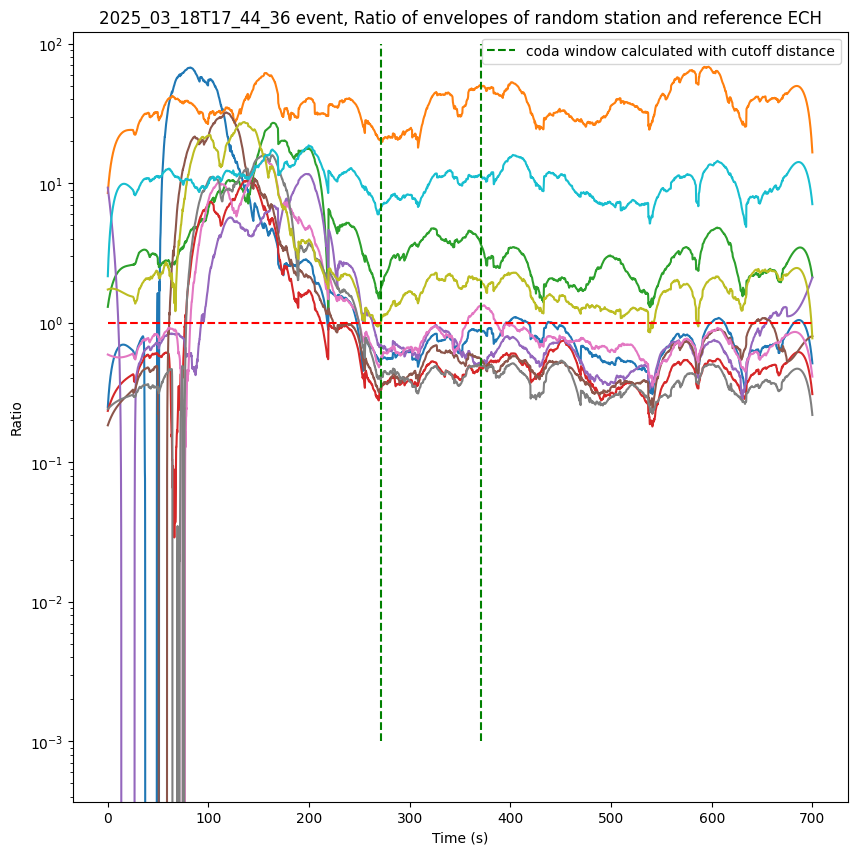

In [13]:
plt.figure(figsize=(10,10))
n_traces = 10
testing = [(randint(1, len(filtered_stream))) for i in range(n_traces)]
for trace_idx in testing:
    trace = filtered_stream[trace_idx]
    plt.semilogy(np.arange(0,700,0.01),savgol_filter(np.divide(resample(trace.data,70000),resample(st_envelope[idx_reference].data,70000)),5000,3))
plt.title(f"{time_string} event, Ratio of envelopes of random station and reference ECH")
plt.vlines(tcoda_cutoff,ymax=1e2,ymin=1e-3, label='coda window calculated with cutoff distance',colors='g',linestyles='--')
plt.vlines(tcoda_cutoff+100,ymax=1e2,ymin=1e-3,colors='g',linestyles='--')
#plt.vlines(tcoda_S,ymax=1e2,ymin=1e-3, label='coda window calculated with S phase',colors='b',linestyles='--')
#plt.vlines(tcoda_S+100,ymax=1e2,ymin=1e-3,colors='b',linestyles='--')
#plt.vlines(tmincoda_dist,ymax=1e2,ymin=1e-3, label='coda window calculated with min Lg velocity',colors='r',linestyles='--')
#plt.vlines(tmincoda_dist+100,ymax=1e2,ymin=1e-3,colors='r',linestyles='--')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Ratio')
plt.hlines(1,xmin=0,xmax=700, linestyles="--",colors='r')

In [7]:
import os

eq_list = pd.read_csv('/home/schreinl/Stage/Data/trial.csv')
eq_list = pd.read_csv('/home/schreinl/Stage/Data/bigger_than_4.5.csv')
catalogue_5 = pd.read_csv('/home/schreinl/Stage/Data/eq_4_france.csv')

catalogue_5 = catalogue_5[catalogue_5['mag'] >= 4.0].reset_index(drop=True)
catalogue_4_5 = pd.read_csv('/home/schreinl/Stage/Data/bigger_than_4.5.csv')
eq_list = catalogue_5
amplitudes_dict = {}

for i in range(len(eq_list)):
    start = UTCDateTime(eq_list["time"][i]) - 25
    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
    magnitude = eq_list["mag"][i]
    
    file_path = f"/home/schreinl/Stage/Data1/{time_string}/{time_string}_envelope_amps_cutoff_fac_1.1_dict.txt"
    print(f"Checking file: {file_path}")
    
    # Check if the file exists
    if not os.path.exists(file_path):
        print(f"File does not exist: {file_path}")
        continue
    
    try:
        with open(file_path, "r") as file:
            amp_dict = json.load(file)
        for station, data in amp_dict.items():
            if station not in amplitudes_dict:
                amplitudes_dict[station] = [None] * i 
            amplitudes_dict[station].append({
                "amplitude": data["amplitude"], 
                "time": time_string, 
                "magnitude": magnitude, 
                "snr_coda": data.get("snr_coda", None), 
                "snr_last_window": data.get("snr_coda_end", None)
            })
        
        for station in amplitudes_dict:
            if station not in amp_dict:
                amplitudes_dict[station].append(None)
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        for station in amplitudes_dict:
            amplitudes_dict[station].append(None)

print(amplitudes_dict["MDI"])


Checking file: /home/schreinl/Stage/Data1/2025_01_12T13_51_15/2025_01_12T13_51_15_envelope_amps_cutoff_fac_1.1_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_06_04T00_34_07/2024_06_04T00_34_07_envelope_amps_cutoff_fac_1.1_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_03_27T21_19_12/2024_03_27T21_19_12_envelope_amps_cutoff_fac_1.1_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_02_17T00_23_04/2024_02_17T00_23_04_envelope_amps_cutoff_fac_1.1_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_02_09T12_05_57/2024_02_09T12_05_57_envelope_amps_cutoff_fac_1.1_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_11_21T05_51_40/2023_11_21T05_51_40_envelope_amps_cutoff_fac_1.1_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_10_28T15_28_57/2023_10_28T15_28_57_envelope_amps_cutoff_fac_1.1_dict.txt
Checking file: /home/schreinl/Stage/Data1/2023_09_18T03_09_49/2023_09_18T03_09_49_envelope_amps_cutoff_fac_1.1_dict.txt
Checking file: /home/schreinl/Stage/Data

In [ ]:
amplitudes_dict = create_coda_amplitude_dict(event_file='/home/schreinl/Stage/Data/eq_4_france.csv', codawindow="cutoff",fmin=2,fmax=3, factor=1.1,data_dir='Data1')

Checking file: /home/schreinl/Stage/Data1/2025_01_12T13_51_15/2025_01_12T13_51_15_envelope_amps_cutoff_fac_1.1_2_2Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2025_01_12T13_51_15/2025_01_12T13_51_15_envelope_amps_cutoff_fac_1.1_2_2Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_06_04T00_34_07/2024_06_04T00_34_07_envelope_amps_cutoff_fac_1.1_2_2Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2024_06_04T00_34_07/2024_06_04T00_34_07_envelope_amps_cutoff_fac_1.1_2_2Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_03_27T21_19_12/2024_03_27T21_19_12_envelope_amps_cutoff_fac_1.1_2_2Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2024_03_27T21_19_12/2024_03_27T21_19_12_envelope_amps_cutoff_fac_1.1_2_2Hz_dict.txt
Checking file: /home/schreinl/Stage/Data1/2024_02_17T00_23_04/2024_02_17T00_23_04_envelope_amps_cutoff_fac_1.1_2_2Hz_dict.txt
File does not exist: /home/schreinl/Stage/Data1/2024_02_17T00_23_04/2024_02_17T00_23_04_envelope_amp

In [ ]:
import folium
import os
import json
import glob

event_map = folium.Map(location=[46.2145, -0.7295], zoom_start=5)

directory = '/home/schreinl/Stage/Data/'

plotted_stations = set()

for event_dir in os.listdir(directory):
    event_path = os.path.join(directory, event_dir)
    if os.path.isdir(event_path):
        file_pattern = os.path.join(event_path, '*_1.5_thresh_stations_with_amps.txt')
        matching_files = glob.glob(file_pattern)
        
        for file_path in matching_files:
            print(f"Processing file: {file_path}")
            try:
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    
                    for station in data:
                        if len(station) >= 4: 
                            network = station[0] 
                            name = station[1]
                            lat = float(station[2])
                            lon = float(station[3]) 
                            
                            if (lat, lon) not in plotted_stations:
                                folium.Marker(
                                    location=[lat, lon],
                                    tooltip=f"{network}.{name} ({lat}, {lon})",
                                    icon=folium.Icon(color='blue', icon='info-sign')
                                ).add_to(event_map)
                                plotted_stations.add((lat, lon))
            except Exception as e:
                print(f"Error processing {file_path}: {e}")


event_map



In [ ]:
import folium
import os
import json
import glob
from geopy.distance import geodesic

event_map = folium.Map(location=[46.2145, -0.7295], zoom_start=5)

data_directory = '/home/schreinl/Stage/Data1/'
metadata_directory = os.path.join(data_directory, "Metadata/")

event_locations = []

for metadata_file in os.listdir(metadata_directory):
    metadata_path = os.path.join(metadata_directory, metadata_file)
    if os.path.isfile(metadata_path):
        try:
            with open(metadata_path, 'r') as file:
                lines = file.readlines()
                lat = None
                lon = None
                
                for line in lines:
                    if line.startswith("Latitude:"):
                        lat = float(line.split(":")[1].strip())
                    elif line.startswith("Longitude:"):
                        lon = float(line.split(":")[1].strip())
                
                if lat is not None and lon is not None:
                    event_locations.append((lat, lon))
        except Exception as e:
            print(f"Error reading {metadata_path}: {e}")

plotted_stations = {}
stations_within_100km = set()
stations_outside_100km = set()

for event_dir in os.listdir(data_directory):
    event_path = os.path.join(data_directory, event_dir)
    if os.path.isdir(event_path):
        file_pattern = os.path.join(event_path, '*_1.1_thresh_stations_with_amps.txt')
        matching_files = glob.glob(file_pattern)
        
        for file_path in matching_files:
            try:
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    
                    for station in data:
                        if len(station) >= 4:
                            network = station[0]
                            name = station[1]
                            lat = float(station[2])
                            lon = float(station[3])
                            station_id = (lat, lon)
                            
                            within_100km = any(geodesic((lat, lon), event_loc).km <= 100 for event_loc in event_locations)

                            if within_100km:
                                stations_within_100km.add(station_id)
                            else:
                                stations_outside_100km.add(station_id)

                            plotted_stations[station_id] = (network, name)

            except Exception as e:
                print(f"Error processing {file_path}: {e}")

print('done reading in')
for (lat, lon), (network, name) in plotted_stations.items():
    color = "green" if (lat, lon) in stations_within_100km else "red"
    folium.Marker(
        location=[lat, lon],
        tooltip=f"{network}.{name} ({lat}, {lon})",
        icon=folium.Icon(color=color)
    ).add_to(event_map)

event_map


### Find fitting Reference station

In [7]:
from obspy.clients.fdsn import Client
import folium

client_resif = Client("RESIF")
client_ingv = Client("INGV")

stations_resif = ["SSB", "ECH", "CHIF", "BALS", "MLS", "CLF"]
stations_ingv = [ "EUCT", "ORO", "MDI"] 

inventory_resif = client_resif.get_stations(network="*", station=",".join(stations_resif), level="station")

inventory_ingv = client_ingv.get_stations(network="*", station=",".join(stations_ingv), level="station")

inventory = inventory_resif + inventory_ingv

origin = [47, 9]
zoom = 5
carte = folium.Map(location=origin, zoom_start=zoom)

for network in inventory_resif:
    for station in network:
        lat = station.latitude
        lon = station.longitude
        name = station.code
        infos = f"{name} ({lat}, {lon})"
        folium.Marker(
            location=[lat, lon],
            tooltip=infos,
            icon=folium.Icon(color='blue', icon='info-sign')
        ).add_to(carte)

for network in inventory_ingv:
    for station in network:
        lat = station.latitude
        lon = station.longitude
        name = station.code
        infos = f"{name} ({lat}, {lon})"
        folium.Marker(
            location=[lat, lon],
            tooltip=infos,
            icon=folium.Icon(color='red', icon='info-sign')
        ).add_to(carte)

carte


In [10]:
fallback_stations = ["SSB", "ECH", "CHIF", "BALS", "MLS", "CLF", "OGMO"]
amplitude_ratios = {}
station2 = "SSB"
total_stations = len(amplitudes_dict.keys())
stations_with_no_valid_ratio = 0

plt.figure(figsize=(12, 8))

for fallback_station in fallback_stations:
    ech_values = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[fallback_station]], dtype=np.float64)
    ssb_values = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station2]], dtype=np.float64)

    ech_values = np.where(ech_values == None, np.nan, ech_values)
    ssb_values = np.where(ssb_values == None, np.nan, ssb_values)

    plt.scatter(events, np.isnan(ech_values), label=f'{fallback_station}', marker='o')

plt.scatter(events, np.isnan(ssb_values), label='SSB', marker='x', color='b')

plt.xlabel("Event")
plt.ylabel("Has Value (0) or NaN (1)")
plt.title("Events with Values for Stations")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


NameError: name 'events' is not defined

<Figure size 1200x800 with 0 Axes>

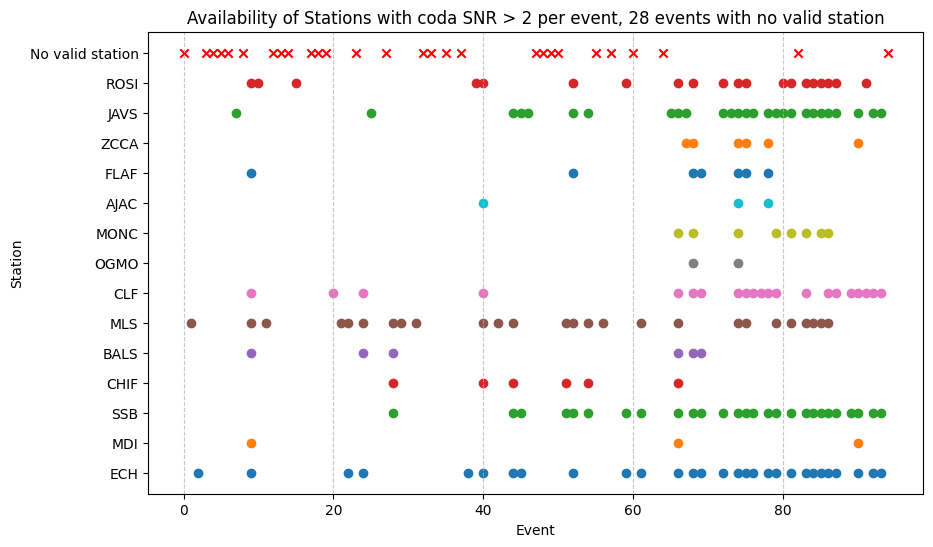

In [5]:
stations_to_plot = ["SSB", "ECH", "FOURG","AJAC", "MLS", "RESF", "ASQU", "MURB","ZCCA","AQU", "PII"]
reference_stations = ["ECH", "MDI", "SSB", "CHIF", "BALS", "MLS", "CLF", "OGMO", "MONC", "AJAC", "FLAF", "ZCCA", "JAVS", "ROSI"]  

stations_to_plot = reference_stations
station2 = "SSB"
counter = 0
events = range(len(amplitudes_dict[station2]))

plt.figure(figsize=(10, 6))

for i, station in enumerate(stations_to_plot):
    values = np.array([entry['amplitude'] if entry is not None and entry.get('snr_coda', 0) > 2 else None for entry in amplitudes_dict[station]], dtype=np.float64)
    values = np.where(values == None, np.nan, values)
    event_indices = [event for event, value in enumerate(values) if not np.isnan(value)]
    count = len(event_indices)
    plt.scatter(event_indices, [i] * len(event_indices), label=f"{station}({count})", marker='o')

for event in events:
    if all(np.isnan([amplitudes_dict[station][event]['amplitude'] if amplitudes_dict[station][event] is not None and amplitudes_dict[station][event].get('snr_coda', 0) > 1.5 else np.nan for station in stations_to_plot])):
        counter += 1
        plt.scatter(event, len(stations_to_plot), color='red', marker='x', label='No valid station' if event == 0 else "")

plt.xlabel("Event")
plt.ylabel("Station")
plt.yticks(range(len(stations_to_plot) + 1), stations_to_plot + ['No valid station'])
plt.title(f"Availability of Stations with coda SNR > 2 per event, {counter} events with no valid station")
#plt.legend(loc='upper right')
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()


Stations to plot: ['ECH', 'MDI', 'SSB', 'CHIF', 'BALS', 'MLS', 'CLF', 'OGMO', 'MONC', 'AJAC', 'FLAF', 'ZCCA', 'JAVS', 'ROSI']


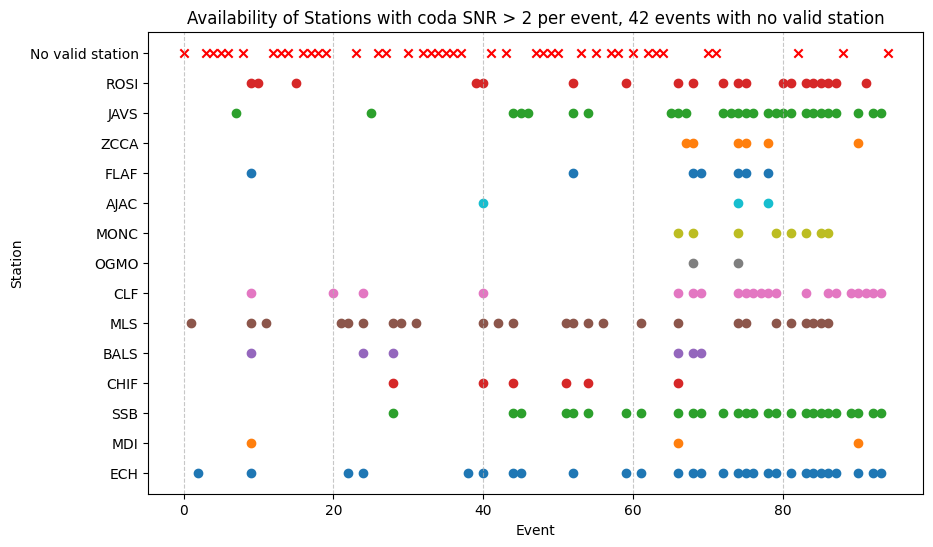

First plot missing event count: 42
Second plot missing event count: 0


In [9]:


stations_to_plot = ["SSB", "ECH", "FOURG", "AJAC", "MLS", "RESF", "ASQU", "MURB", "ZCCA", "AQU", "PII"]
reference_stations = ["ECH", "MDI", "SSB", "CHIF", "BALS", "MLS", "CLF", "OGMO", "MONC", "AJAC", "FLAF", "ZCCA", "JAVS", "ROSI"]

stations_to_plot = reference_stations
station2 = "ECH"
counter = 0
events = range(len(amplitudes_dict[station2]))

print("Stations to plot:", stations_to_plot)

plt.figure(figsize=(10, 6))

for i, station in enumerate(stations_to_plot):
    values = np.array([
        entry['amplitude'] if entry is not None and entry.get('snr_coda', 0) > 2 else None
        for entry in amplitudes_dict[station]
    ], dtype=np.float64)
    values = np.where(values == None, np.nan, values)
    event_indices = [event for event, value in enumerate(values) if not np.isnan(value)]
    count = len(event_indices)
    plt.scatter(event_indices, [i] * len(event_indices), label=f"{station}({count})", marker='o')

# Use consistent SNR threshold (>2) for missing event calculation
for event in events:
    if all(np.isnan([
        amplitudes_dict[station][event]['amplitude']
        if amplitudes_dict[station][event] is not None and amplitudes_dict[station][event].get('snr_coda', 0) > 2
        else np.nan
        for station in stations_to_plot
    ])):
        counter += 1
        plt.scatter(event, len(stations_to_plot), color='red', marker='x', label='No valid station' if event == 0 else "")

plt.xlabel("Event")
plt.ylabel("Station")
plt.yticks(range(len(stations_to_plot) + 1), stations_to_plot + ['No valid station'])
plt.title(f"Availability of Stations with coda SNR > 2 per event, {counter} events with no valid station")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

# Debugging print
print(f"First plot missing event count: {counter}")


low_snr_events = []

for i in range(len(eq_list)):
    start = UTCDateTime(eq_list["time"][i]) - 25
    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
    
    file_path = f"/home/schreinl/Stage/Data1/{time_string}/{time_string}_envelope_amps_cutoff_fac_1.1_3_4Hz_dict.txt"
    
    if not os.path.exists(file_path):
        continue  # Ensure we don't count missing files

    with open(file_path, "r") as file:
        amp_dict = json.load(file)

    # Ensure we use snr_coda > 2 consistently
    all_below_threshold = all(
        station in amp_dict and amp_dict[station].get("snr_coda", 0) <= 2
        for station in stations_to_plot
    )

    if all_below_threshold:
        low_snr_events.append(i)

filtered_eq_list = eq_list.iloc[low_snr_events].reset_index(drop=True)

# Debugging print
print(f"Second plot missing event count: {len(filtered_eq_list)}")

# Generate the map
carte = folium.Map([45, 7], zoom_start=5)

for _, row in filtered_eq_list.iterrows():
    infos = f"{row['time']} ({row['latitude']}, {row['longitude']}) {row['mag']} m"
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        tooltip=infos,
        fill=True,
        fill_opacity=1.0,
        radius=4,
    ).add_to(carte)

carte


In [10]:


low_snr_events = []

for i in range(len(eq_list)):
    start = UTCDateTime(eq_list["time"][i]) - 25
    time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
    
    file_path = f"/home/schreinl/Stage/Data1/{time_string}/{time_string}_envelope_amps_cutoff_fac_1.1_3_4Hz_dict.txt"
    
    if not os.path.exists(file_path):
        continue
    
    with open(file_path, "r") as file:
        amp_dict = json.load(file)
    
    all_below_threshold = True
    for station in stations_to_plot:
        if station in amp_dict and amp_dict[station].get("snr_coda", 0) > 2:
            all_below_threshold = False
            break
    
    if all_below_threshold:
        low_snr_events.append(i)

filtered_eq_list = eq_list.iloc[low_snr_events].reset_index(drop=True)
print(len(filtered_eq_list))
carte = folium.Map([45, 7], zoom_start=5)

for _, row in filtered_eq_list.iterrows():
    infos = f"{row['time']} ({row['latitude']}, {row['longitude']}) {row['mag']} m"
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        tooltip=infos,
        fill=True,
        fill_opacity=1.0,
        radius=4,
    ).add_to(carte)

carte

42


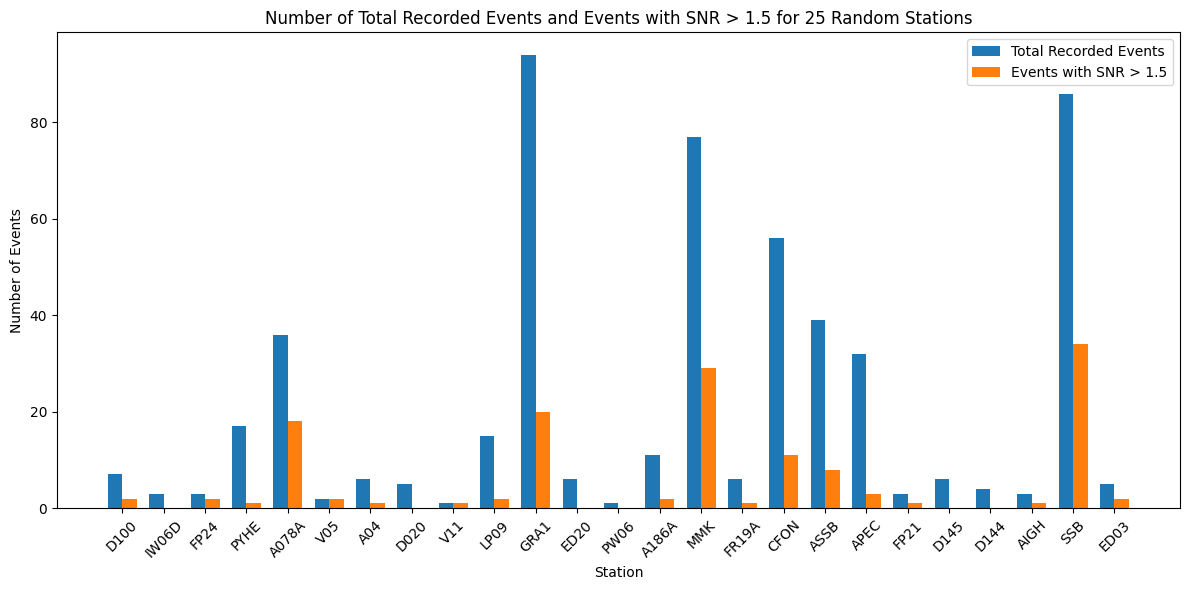

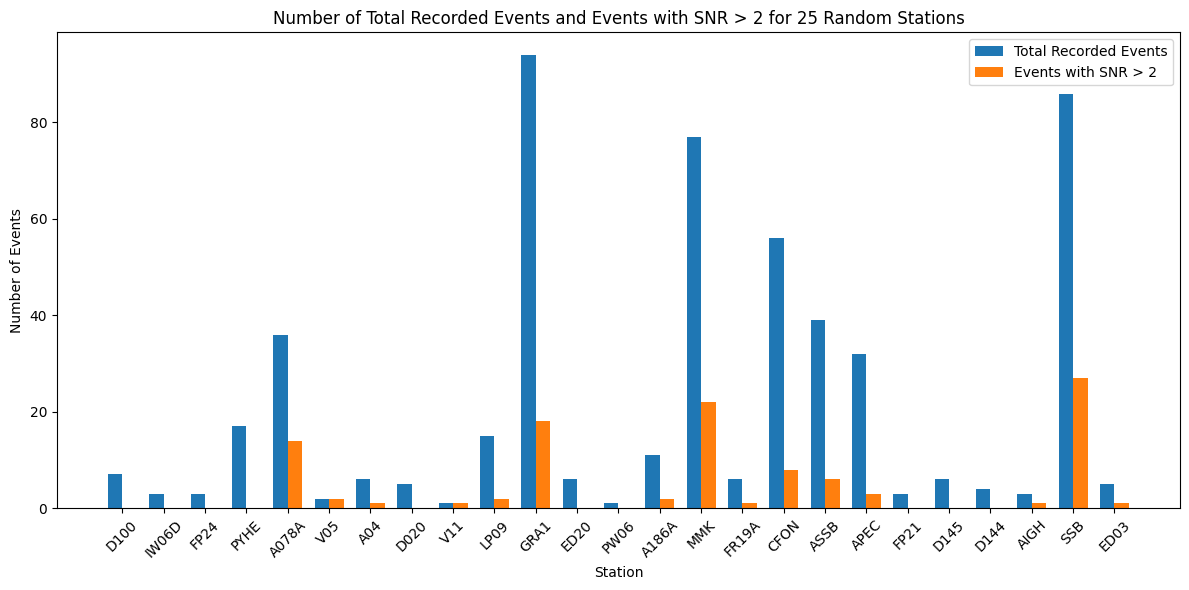

In [11]:
station_data = {}

random_stations = random.sample(list(amplitudes_dict.keys()), 25)

for station in random_stations:
    amplitudes = amplitudes_dict[station]
    recorded_count = sum(amp is not None for amp in amplitudes)
    snr_over_1_5 = sum(entry['snr_coda'] > 1.5 if entry is not None and 'snr_coda' in entry else False for entry in amplitudes)
    snr_over_2 = sum(entry['snr_coda'] > 2 if entry is not None and 'snr_coda' in entry else False for entry in amplitudes)
    station_data[station] = {
        'recorded_count': recorded_count,
        'snr_over_1_5': snr_over_1_5,
        'snr_over_2': snr_over_2
    }

stations = list(station_data.keys())
recorded_counts = [station_data[station]['recorded_count'] for station in stations]
snr_over_1_5_counts = [station_data[station]['snr_over_1_5'] for station in stations]
snr_over_2_counts = [station_data[station]['snr_over_2'] for station in stations]

plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(stations))

plt.bar(index, recorded_counts, bar_width, label='Total Recorded Events')
plt.bar([i + bar_width for i in index], snr_over_1_5_counts, bar_width, label='Events with SNR > 1.5')

plt.xlabel('Station')
plt.ylabel('Number of Events')
plt.title('Number of Total Recorded Events and Events with SNR > 1.5 for 25 Random Stations')
plt.xticks([i + bar_width / 2 for i in index], stations, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(stations))

plt.bar(index, recorded_counts, bar_width, label='Total Recorded Events')
plt.bar([i + bar_width for i in index], snr_over_2_counts, bar_width, label='Events with SNR > 2')

plt.xlabel('Station')
plt.ylabel('Number of Events')
plt.title('Number of Total Recorded Events and Events with SNR > 2 for 25 Random Stations')
plt.xticks([i + bar_width / 2 for i in index], stations, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


Mean Ratio (MONC / SSB): 6.52157
Standard Deviation: 6.16427
Median: 4.56102
Min Ratio: 1.13999
Max Ratio: 36.93202


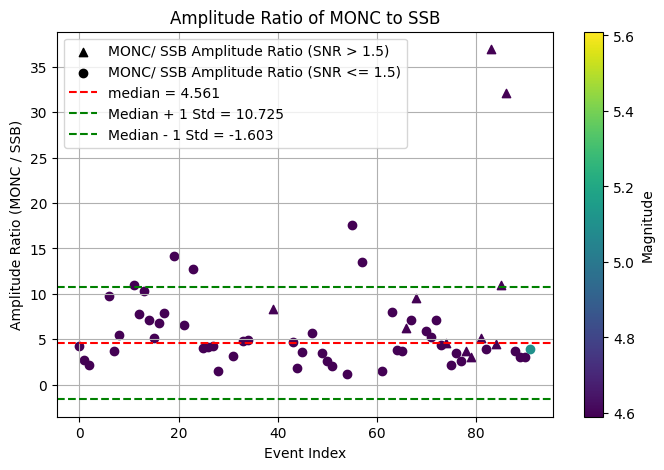

In [12]:
station1 = "MONC"
station2 = "SSB"

denom_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station1]], dtype=np.float64)
counter_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station2]], dtype=np.float64)

denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
valid_ratios = ratio[~np.isnan(ratio)]
mean_ratio = np.nanmean(valid_ratios)
std_ratio = np.nanstd(valid_ratios)
median_ratio = np.nanmedian(valid_ratios)
min_ratio = np.nanmin(valid_ratios)
max_ratio = np.nanmax(valid_ratios)

magnitudes = np.array([entry['magnitude'] if entry is not None else None for entry in amplitudes_dict[station1]], dtype=np.float64)
magnitudes = np.where(magnitudes == None, np.nan, magnitudes)

print(f"Mean Ratio ({station1} / {station2}): {mean_ratio:.5f}")
print(f"Standard Deviation: {std_ratio:.5f}")
print(f"Median: {median_ratio:.5f}")
print(f"Min Ratio: {min_ratio:.5f}")
print(f"Max Ratio: {max_ratio:.5f}")

plt.figure(figsize=(8, 5))
plt.scatter([], [], c='k', marker="^", label=f"{station1}/ {station2} Amplitude Ratio (SNR > 1.5)")
plt.scatter([], [], c='k', marker="o", label=f"{station1}/ {station2} Amplitude Ratio (SNR <= 1.5)")

for i, (r, mag) in enumerate(zip(ratio, magnitudes)):
    if not np.isnan(r):
        snr_coda = amplitudes_dict[station1][i].get('snr_coda', None)
        if snr_coda is not None and snr_coda > 1.5:
            plt.scatter(i, r, c=mag, cmap='viridis', marker="^")
        else:
            plt.scatter(i, r, c=mag, cmap='viridis', marker="o")

plt.colorbar(label='Magnitude')
plt.axhline(median_ratio, color="r", linestyle="--", label=f"median = {median_ratio:.3f}")
plt.axhline(median_ratio + std_ratio, color="g", linestyle="--", label=f"Median + 1 Std = {median_ratio + std_ratio:.3f}")
plt.axhline(median_ratio - std_ratio, color="g", linestyle="--", label=f"Median - 1 Std = {median_ratio - std_ratio:.3f}")

plt.xlabel("Event Index")
plt.ylabel(f"Amplitude Ratio ({station1} / {station2})")
plt.title(f"Amplitude Ratio of {station1} to {station2}")
plt.legend()
plt.grid(True)
plt.show()


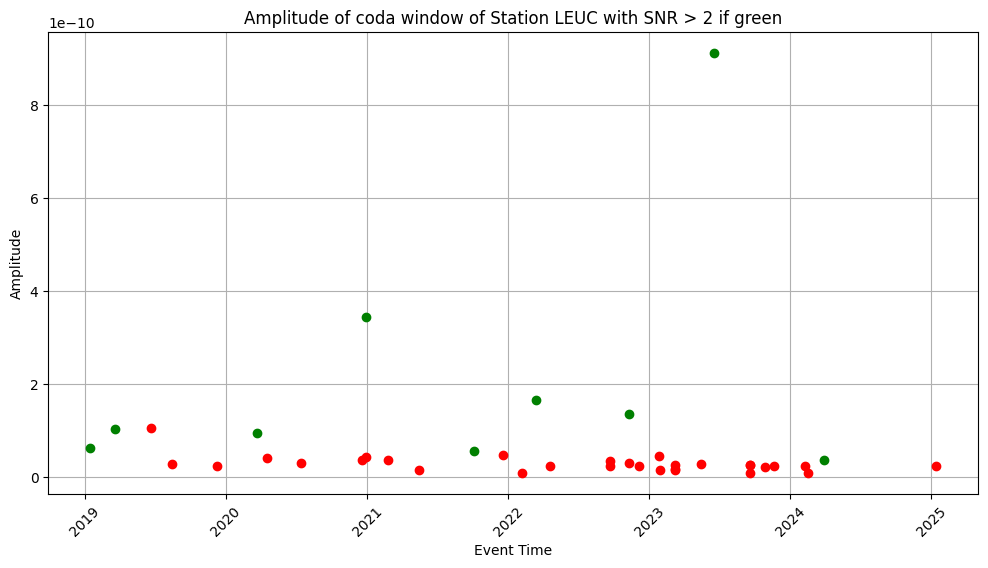

In [13]:
stationcheck = "LEUC"
from datetime import datetime
ech_amplitudes = [entry['amplitude'] if entry is not None else np.nan for entry in amplitudes_dict[stationcheck]]
snr_coda_values = [entry['snr_coda'] if entry is not None else np.nan for entry in amplitudes_dict[stationcheck]]
event_times = [entry['time'] if entry is not None else 'None' for entry in amplitudes_dict['ECH']]
valid_indices = [i for i, time in enumerate(event_times) if time != 'None']
valid_times = [event_times[i] for i in valid_indices]
valid_amplitudes = [ech_amplitudes[i] for i in valid_indices]
valid_snr_coda = [snr_coda_values[i] for i in valid_indices]
valid_times = [datetime.strptime(time, '%Y_%m_%dT%H_%M_%S') for time in valid_times]

plt.figure(figsize=(12, 6))
for time, amplitude, snr_coda in zip(valid_times, valid_amplitudes, valid_snr_coda):
    if snr_coda is not None:
        color = 'green' if snr_coda > 2 else 'red'
        plt.plot(time, amplitude, 'o', color=color)
#plt.text(0.5, 0.5, 'Green: SNR > 2', color='green')
#plt.text(0.5, 0.5, 'Red: SNR <= 2', color='red')
plt.xlabel('Event Time')
plt.ylabel('Amplitude')
plt.title(f'Amplitude of coda window of Station {stationcheck} with SNR > 2 if green')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

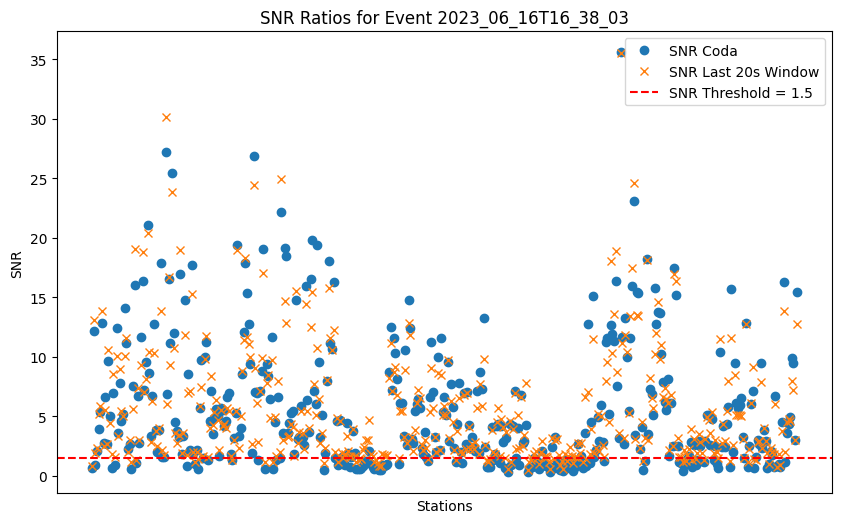

In [19]:
event_index = 9

snr_coda_event = []
snr_last_window_event = []
stations_with_snr = []

for station, data_list in amplitudes_dict.items():
    if data_list[event_index] is not None:
        snr_coda = data_list[event_index].get("snr_coda", None)
        snr_last_window = data_list[event_index].get("snr_last_window", None)
        time = data_list[event_index].get("time", None)
        if snr_coda is not None and snr_last_window is not None:
            snr_coda_event.append(snr_coda)
            snr_last_window_event.append(snr_last_window)
            stations_with_snr.append(station)

plt.figure(figsize=(10, 6))
plt.plot(stations_with_snr, snr_coda_event, 'o', label='SNR Coda')
plt.plot(stations_with_snr, snr_last_window_event, 'x', label='SNR Last 20s Window')
plt.axhline(1.5, color='r', linestyle='--', label='SNR Threshold = 1.5')
plt.xlabel('Stations')
plt.ylabel('SNR')
plt.title(f'SNR Ratios for Event {time}')
plt.legend()
plt.xticks([])
plt.show()


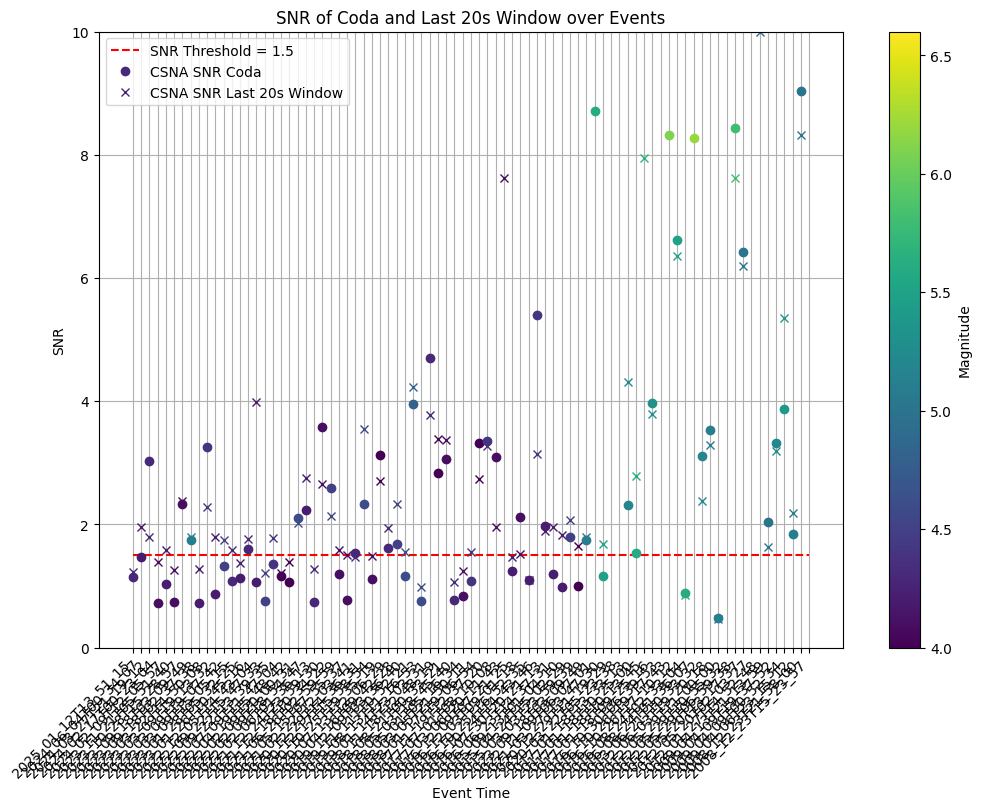

In [14]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

stations_to_plot = ["CSNA"]
events = range(len(amplitudes_dict[station2]))

fig, ax = plt.subplots(figsize=(12, 8))

for station in stations_to_plot:
    snr_coda_values = np.array([entry['snr_coda'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    snr_last_window_values = np.array([entry['snr_last_window'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    magnitudes = np.array([entry['magnitude'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    times = np.array([entry['time'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=str)
    
    valid_indices = [i for i, time in enumerate(times) if time != 'None']
    valid_times = [times[i] for i in valid_indices]
    snr_coda_values = snr_coda_values[valid_indices]
    snr_last_window_values = snr_last_window_values[valid_indices]
    magnitudes = magnitudes[valid_indices]
    
    norm = mcolors.Normalize(vmin=np.nanmin(magnitudes), vmax=np.nanmax(magnitudes))
    cmap = cm.viridis

    ax.hlines(1.5, 0, len(valid_times) - 1, colors='r', linestyles='--', label='SNR Threshold = 1.5')
    label_coda = f'{station} SNR Coda'
    label_last = f'{station} SNR Last 20s Window'
    for i, (snr_coda, snr_last, mag) in enumerate(zip(snr_coda_values, snr_last_window_values, magnitudes)):
        if not np.isnan(snr_coda):
            ax.plot(i, snr_coda, 'o', color=cmap(norm(mag)), label=label_coda)
            label_coda = ""  # Clear the label after the first use
        if not np.isnan(snr_last):
            ax.plot(i, snr_last, 'x', color=cmap(norm(mag)), label=label_last)
            label_last = ""  # Clear the label after the first use

ax.set_xticks(range(len(valid_times)))
ax.set_xticklabels(valid_times, rotation=45, ha='right')
ax.set_xlabel("Event Time")
ax.set_ylabel("SNR")
ax.set_ylim(0,10)
ax.set_title("SNR of Coda and Last 20s Window over Events")
ax.legend()
ax.grid(True)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Magnitude')
plt.show()


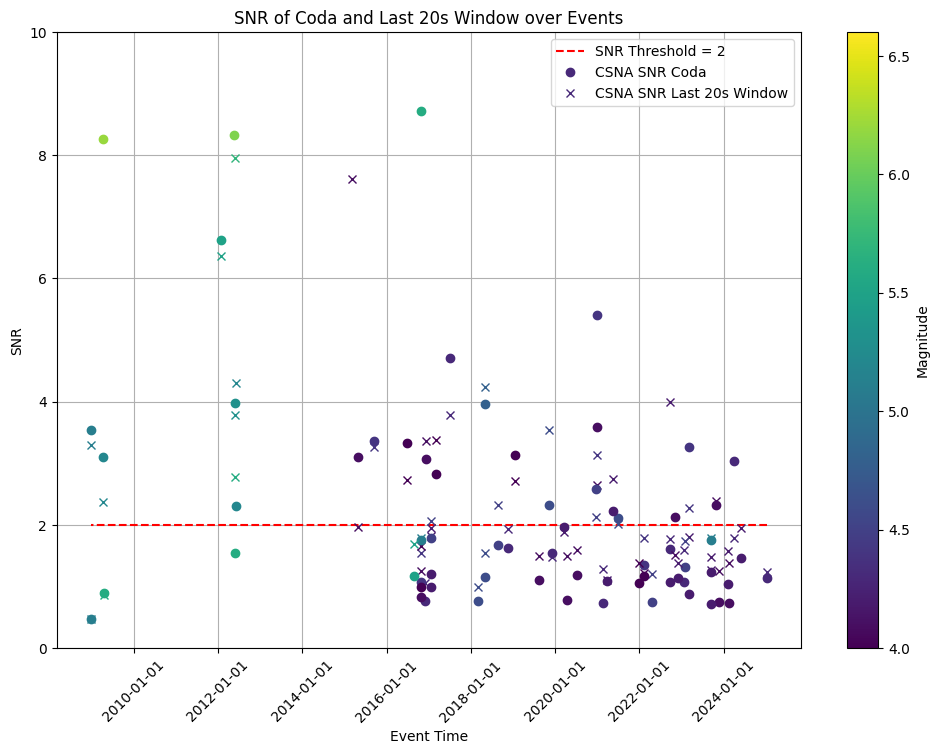

In [17]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

stations_to_plot = ["CSNA"]
events = range(len(amplitudes_dict[station2]))

fig, ax = plt.subplots(figsize=(12, 8))

for station in stations_to_plot:
    snr_coda_values = np.array([entry['snr_coda'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    snr_last_window_values = np.array([entry['snr_last_window'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    magnitudes = np.array([entry['magnitude'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    times = np.array([entry['time'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=str)
    
    valid_times = [datetime.strptime(time, '%Y_%m_%dT%H_%M_%S') for time in times if time != 'None']
    snr_coda_values = np.where(snr_coda_values == None, np.nan, snr_coda_values)
    snr_last_window_values = np.where(snr_last_window_values == None, np.nan, snr_last_window_values)
    magnitudes = np.where(magnitudes == None, np.nan, magnitudes)
    #print(times)
    #print(snr_coda_values)
    norm = mcolors.Normalize(vmin=np.nanmin(magnitudes), vmax=np.nanmax(magnitudes))
    cmap = cm.viridis

    ax.hlines(2, valid_times[0], valid_times[-1], colors='r', linestyles='--', label='SNR Threshold = 2')
    label_coda = f'{station} SNR Coda'
    label_last = f'{station} SNR Last 20s Window'
    for i, (snr_coda, snr_last, mag, time) in enumerate(zip(snr_coda_values, snr_last_window_values, magnitudes, valid_times)):
        if not np.isnan(snr_coda):
            ax.plot(time, snr_coda, 'o', color=cmap(norm(mag)), label=label_coda)
            label_coda = ""  # Clear the label after the first use
        if not np.isnan(snr_last):
            ax.plot(time, snr_last, 'x', color=cmap(norm(mag)), label=label_last)
            label_last = ""  # Clear the label after the first use

ax.set_xlabel("Event Time")
ax.set_ylabel("SNR")
ax.set_ylim(0,10)
ax.set_title("SNR of Coda and Last 20s Window over Events")
ax.legend()
ax.grid(True)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Magnitude')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.show()


Total stations: 1786
Stations with at least one valid recording: 1243
Stations with no valid recordings: 543
Earthquakes with at least one reference station recording: 73
 22 Events without reference station recording: [3, 4, 5, 8, 10, 12, 13, 14, 15, 17, 18, 19, 20, 27, 32, 35, 48, 50, 55, 57, 82, 94]


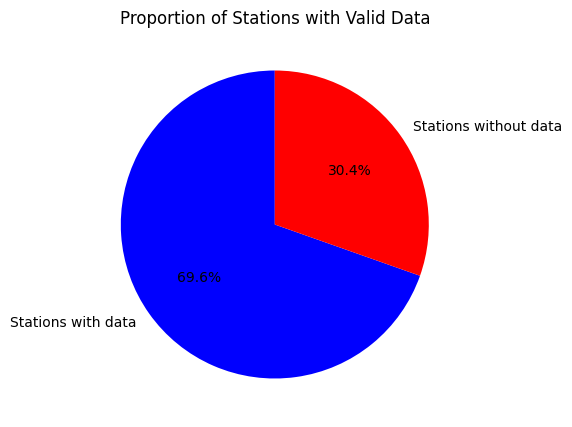

In [24]:
reference_stations = ["ECH", "MDI", "SSB", "CHIF", "BALS", "MLS", "CLF", "OGMO", "MONC", "AJAC", "FLAF", "ZCCA", "JAVS", "ROSI"] 
reference_stations = ['MLS','ECH','LOR','CSNA','CONA','HASLI','SENIN','BOURR','DAVOX','BNALP','MOA','KHC','FUORN'] 
#reference_stations = stations_to_plot
valid_stations = set()
total_stations = set(amplitudes_dict.keys())
earthquake_counts = 0
events_without_reference = []

for event_idx in range(len(next(iter(amplitudes_dict.values())))):
    ref_station_recorded = any(
        amplitudes_dict[ref_station][event_idx] is not None and 
        amplitudes_dict[ref_station][event_idx].get("snr_coda", 0) > 1.5
        for ref_station in reference_stations if ref_station in amplitudes_dict
    )

    if ref_station_recorded:
        earthquake_counts += 1
        for station in amplitudes_dict.keys():
            entry = amplitudes_dict[station][event_idx]
            if entry is not None and entry.get("snr_coda", 0) > 1.5:
                valid_stations.add(station)
    else:
        events_without_reference.append(event_idx)

num_valid_stations = len(valid_stations)
num_non_valid_stations = len(total_stations - valid_stations)

print(f"Total stations: {len(total_stations)}")
print(f"Stations with at least one valid recording: {num_valid_stations}")
print(f"Stations with no valid recordings: {num_non_valid_stations}")
print(f"Earthquakes with at least one reference station recording: {earthquake_counts}")
print(f" {len(events_without_reference)} Events without reference station recording: {events_without_reference}")

plt.figure(figsize=(8, 5))
labels = ["Stations with data", "Stations without data"]
sizes = [num_valid_stations, num_non_valid_stations]
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=["blue", "red"], startangle=90)
plt.title("Proportion of Stations with Valid Data")
plt.show()


In [ ]:
import folium
import os
import json
import glob

event_map = folium.Map(location=[46.2145, -0.7295], zoom_start=5)

data_directory = '/home/schreinl/Stage/Data1/'

for event_dir in os.listdir(data_directory):
    event_path = os.path.join(data_directory, event_dir)
    if os.path.isdir(event_path):
        file_pattern = os.path.join(event_path, '*thresh_filtered_stations_SNR.txt')
        matching_files = glob.glob(file_pattern)
        
        for file_path in matching_files:
            print(f"Processing file: {file_path}")
            try:
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    
                    for station in data:
                        if len(station) >= 4:
                            network = station[0]
                            name = station[1]
                            lat = float(station[2])
                            lon = float(station[3])
                            
                            folium.Marker(
                                location=[lat, lon],
                                tooltip=f"{network}.{name} ({lat}, {lon})",
                                icon=folium.Icon(color='blue', icon='info-sign')
                            ).add_to(event_map)
            except Exception as e:
                print(f"Error processing {file_path}: {e}")

# Display the map
event_map


In [25]:
remaining_events = events_without_reference
station_event_counts = {station: 0 for station in amplitudes_dict.keys()}

for event_idx in remaining_events:
    for station, entries in amplitudes_dict.items():
        entry = entries[event_idx]
        if entry is not None and entry.get("snr_coda", 0) > 1.5:
            station_event_counts[station] += 1

sorted_stations = sorted(station_event_counts.items(), key=lambda x: x[1], reverse=True)
top_5_stations = sorted_stations[:5]

for station, count in top_5_stations:
    print(f"Station: {station}, Events with coda SNR > 1.5: {count}")


Station: SMPL, Events with coda SNR > 1.5: 3
Station: SROF, Events with coda SNR > 1.5: 3
Station: FIAM, Events with coda SNR > 1.5: 3
Station: RNI2, Events with coda SNR > 1.5: 3
Station: SENA, Events with coda SNR > 1.5: 3


Total number of stations: 1786
Number of stations with no valid ratio: 598


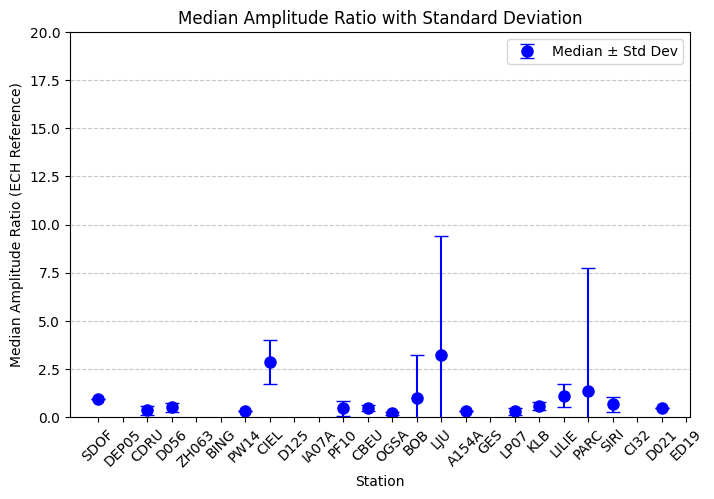

In [26]:
import random

station2 = "ECH"
fallback_stations = reference_stations
amplitude_ratios = {}

total_stations = len(amplitudes_dict.keys())
stations_with_no_valid_ratio = 0

for station1 in amplitudes_dict.keys():
    denom_amplitudes = np.array([entry['amplitude'] if entry is not None and entry.get('snr_coda', 0) is not None and entry.get('snr_coda', 0) > 1.5 else None for entry in amplitudes_dict[station1]], dtype=np.float64)
    counter_amplitudes = np.array([entry['amplitude'] if entry is not None and entry.get('snr_coda', 0) is not None and entry.get('snr_coda', 0) > 1.5 else None for entry in amplitudes_dict[station2]], dtype=np.float64)

    denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
    counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

    if np.isnan(counter_amplitudes).all():
        for fallback_station in fallback_stations:
            counter_amplitudes = np.array([entry['amplitude'] if entry is not None and entry.get('snr_coda', 0) is not None and entry.get('snr_coda', 0) > 1.5 else None for entry in amplitudes_dict[fallback_station]], dtype=np.float64)
            counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)
            if not np.isnan(counter_amplitudes).all():
                print(f"Using fallback station {fallback_station} for station {station1}")
                break

    ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
    valid_ratios = ratio[~np.isnan(ratio)]
    
    if len(valid_ratios) > 0:
        amplitude_ratios[station1] = {
            "median": np.nanmedian(valid_ratios),
            "std": np.nanstd(valid_ratios),
        }
    else:
        amplitude_ratios[station1] = {
            "median": np.nan,
            "std": np.nan,
        }
        stations_with_no_valid_ratio += 1

print(f"Total number of stations: {total_stations}")
print(f"Number of stations with no valid ratio: {stations_with_no_valid_ratio}")

stations_list = list(amplitude_ratios.keys())
station_tests = random.sample(list(amplitudes_dict.keys()), 25)
median_values = [amplitude_ratios[st]["median"] for st in station_tests]
std_values = [amplitude_ratios[st]["std"] for st in station_tests]

plt.figure(figsize=(8, 5))
plt.errorbar(station_tests, median_values, yerr=std_values, fmt='o', capsize=5, markersize=8, color="b", label="Median ± Std Dev")

plt.xlabel("Station")
plt.ylabel(f"Median Amplitude Ratio ({station2} Reference)")
plt.title(f"Median Amplitude Ratio with Standard Deviation")
plt.legend()
plt.ylim(0, 20)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.show()



Total number of stations: 1786
Number of stations with no valid ratio: 649


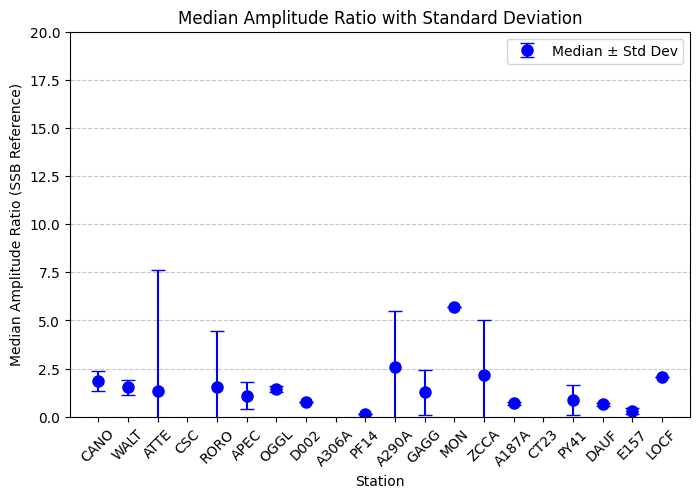

In [27]:
import numpy as np
import random
import matplotlib.pyplot as plt

station2 = "SSB"
fallback_stations = ["BALS","ECH", "MLS", "CHIF"]
amplitude_ratios = {}

total_stations = len(amplitudes_dict.keys())
stations_with_no_valid_ratio = 0

for station1 in amplitudes_dict.keys():
    denom_amplitudes = np.array([
        entry['amplitude'] if entry is not None and entry.get('snr_coda') is not None and entry['snr_coda'] > 1.5 else np.nan
        for entry in amplitudes_dict[station1]
    ])
    
    counter_amplitudes = np.array([
        entry['amplitude'] if entry is not None and entry.get('snr_coda') is not None and entry['snr_coda'] > 1.5 else np.nan
        for entry in amplitudes_dict.get(station2, [])
    ])

    # If the reference station has no valid amplitudes, check fallback stations
    if np.isnan(counter_amplitudes).all():
        found_fallback = False  # Flag to check if we find a valid fallback
        for fallback_station in fallback_stations:
            fallback_amplitudes = np.array([
                entry['amplitude'] if entry is not None and entry.get('snr_coda') is not None and entry['snr_coda'] > 1.5 else np.nan
                for entry in amplitudes_dict.get(fallback_station, [])
            ])
            if not np.isnan(fallback_amplitudes).all():  # If fallback station has valid data
                counter_amplitudes = fallback_amplitudes  # Use fallback station
                print(f"Using fallback station {fallback_station} for station {station1}")
                found_fallback = True
                break  # Stop after finding the first valid fallback

        if not found_fallback:
            print(f"No valid fallback station found for {station1}")

    ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
    valid_ratios = ratio[~np.isnan(ratio)]

    if len(valid_ratios) > 0:
        amplitude_ratios[station1] = {
            "median": np.nanmedian(valid_ratios),
            "std": np.nanstd(valid_ratios),
        }
    else:
        amplitude_ratios[station1] = {
            "median": np.nan,
            "std": np.nan,
        }
        stations_with_no_valid_ratio += 1


print(f"Total number of stations: {total_stations}")
print(f"Number of stations with no valid ratio: {stations_with_no_valid_ratio}")

stations_list = list(amplitude_ratios.keys())
station_tests = random.choices(list(amplitudes_dict.keys()), k=min(25, len(amplitudes_dict)))

median_values = [amplitude_ratios[st]["median"] for st in station_tests]
std_values = [amplitude_ratios[st]["std"] for st in station_tests]

plt.figure(figsize=(8, 5))
plt.errorbar(station_tests, median_values, yerr=std_values, fmt='o', capsize=5, markersize=8, color="b", label="Median ± Std Dev")

plt.xlabel("Station")
plt.ylabel(f"Median Amplitude Ratio ({station2} Reference)")
plt.title("Median Amplitude Ratio with Standard Deviation")
plt.legend()
plt.ylim(0, 20)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.show()


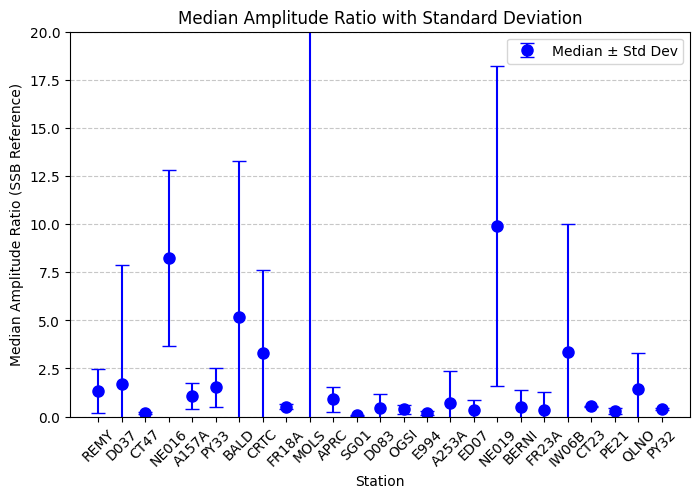

In [29]:
station2 = "SSB"
amplitude_ratios = {}

for station1 in amplitudes_dict.keys():
    denom_amplitudes = np.array([entry['amplitude'] if entry is not None else np.nan for entry in amplitudes_dict[station1]], dtype=np.float64)
    counter_amplitudes = np.array([entry['amplitude'] if entry is not None else np.nan for entry in amplitudes_dict[station2]], dtype=np.float64)

    denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
    counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

    ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
    valid_ratios = ratio[~np.isnan(ratio)]
    
    if len(valid_ratios) > 0:
        amplitude_ratios[station1] = {
            "median": np.nanmedian(valid_ratios),
            "std": np.nanstd(valid_ratios),
        }
    else:
        amplitude_ratios[station1] = {
            "median": np.nan,
            "std": np.nan,
        }

stations_list = list(amplitude_ratios.keys())
station_tests = random.sample(list(amplitudes_dict.keys()), 25)
median_values = [amplitude_ratios[st]["median"] for st in station_tests]
std_values = [amplitude_ratios[st]["std"] for st in station_tests]

plt.figure(figsize=(8, 5))
plt.errorbar(station_tests, median_values, yerr=std_values, fmt='o', capsize=5, markersize=8, color="b", label="Median ± Std Dev")

plt.xlabel("Station")
plt.ylabel(f"Median Amplitude Ratio ({station2} Reference)")
plt.title(f"Median Amplitude Ratio with Standard Deviation")
plt.legend()
plt.ylim(0, 20)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45)
plt.show()


In [ ]:
station_tests = random.sample(list(amplitudes_dict.keys()), 25)
print(len(station_tests))
plt.figure(figsize=(12, 8))

for i, station in enumerate(station_tests):
    median = amplitude_ratios[station]["median"]
    max_std = np.nanpercentile([amplitude_ratios[station]["std"] for station in station_tests], 95) 
    std = min(amplitude_ratios[station]["std"], max_std) 
    #std = amplitude_ratios[station]["std"]
    
    denom_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station]], dtype=np.float64)
    counter_amplitudes = np.array([entry['amplitude'] if entry is not None else None for entry in amplitudes_dict[station2]], dtype=np.float64)

    denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
    counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

    ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
    valid_ratios = ratio[~np.isnan(ratio)]
    
    count = len(valid_ratios)
    
    plt.errorbar(station, median, yerr=std, fmt='o', capsize=5, markersize=8, color="b", label="Median ± Std Dev" if i == 0 else "")
    plt.text(i, median + std + 0.2, f"{count}", ha="center", fontsize=10, color="red")

plt.xticks(rotation=45)
plt.xlabel("Station")
plt.ylim(0, 20)
plt.ylabel(f"Median Amplitude Ratio ({station2} Reference)")
plt.title(f"Median Amplitude Ratio with Standard Deviation")
plt.legend(loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.text(24.6, 18, "Number of ratios used", color="red", ha="right", fontsize=10)
plt.show()


Total number of stations: 1770
Number of stations with no valid ratio: 93


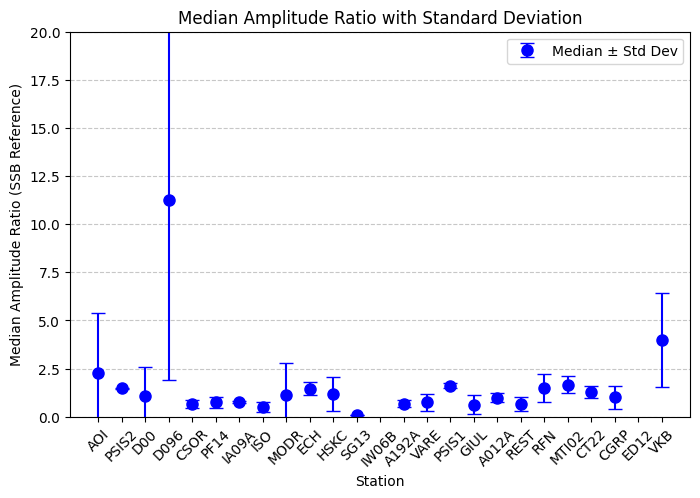

In [58]:
def site_effect(eq_file='/home/schreinl/Stage/Data/eq_4_france.csv', codafile='envelope_amps_fac_1.5_dict',sample_size=25,ref_station1 = "SSB", ref_station2 = "ECH", ratio_plot = False):
    '''
    Function calculates the site effect for each station by building the median amplitude ratio of each station to the reference station.
    For each event and for each station the site effect is calculated.
    output should be one large
    Inputs: earthquakes in a list, codafile which is the ending of the files that contain the amplitudes
    Output: a dictionary with the site effect for each station

    '''

    #read in the earthquake list
    eq_list = pd.read_csv(eq_file)

    #create the dictionary
    amplitudes_dict = {}

    #fill the dict with the amplitudes, so for a specific coda window file the amplitudes are read in
    for i in range(len(eq_list)):
        start = UTCDateTime(eq_list["time"][i])
        time_string = UTCDateTime.strftime(start, format="%Y_%m_%dT%H_%M_%S")
        
        try:    #/home/schreinl/Stage/Data/{time_string}/{time_string}_envelope_amps_fac_1.5_dict.txt
            with open(f"/home/schreinl/Stage/Data/{time_string}/{time_string}_{codafile}.txt", "r") as file:
                amp_dict = json.load(file)

            for station, data in amp_dict.items():
                if station not in amplitudes_dict:
                    amplitudes_dict[station] = [None] * i 
                amplitudes_dict[station].append(data["amplitude"])
            
            for station in amplitudes_dict:
                if station not in amp_dict:
                    amplitudes_dict[station].append(None)
        except FileNotFoundError:
            for station in amplitudes_dict:
                amplitudes_dict[station].append(None)

        #so now we have a dictionary with the amplitudes for each station for each event, so dimensions are N number of events given,
        # and M number of stations that have recorded at least one event

    # if we wanted to test what we did, we use a smaller batch size of stations
    sample_size = min(sample_size, len(amplitudes_dict.keys()))
    station_tests = random.sample(list(amplitudes_dict.keys()), sample_size)

    #here we choose the reference stations
    station2 = ref_station1
    fallback_station = ref_station2
    amplitude_ratios = {}

    # Counters for stations with and without valid ratios
    total_stations = len(amplitudes_dict.keys())
    stations_with_no_valid_ratio = 0

    for station1 in amplitudes_dict.keys():
        denom_amplitudes = np.array(amplitudes_dict[station1], dtype=np.float64)
        counter_amplitudes = np.array(amplitudes_dict[station2], dtype=np.float64)

        # Replace None with np.nan
        denom_amplitudes = np.where(denom_amplitudes == None, np.nan, denom_amplitudes)
        counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

        # Check if the reference station has missing values and use fallback if necessary
        
        # Check if the reference station has missing values and use fallback if necessary
        if np.isnan(counter_amplitudes).all():
            print(f"Using fallback station {fallback_station} for station {station1}")
            counter_amplitudes = np.array(amplitudes_dict[fallback_station], dtype=np.float64)
            counter_amplitudes = np.where(counter_amplitudes == None, np.nan, counter_amplitudes)

        # Calculate the ratio
        ratio = np.divide(denom_amplitudes, counter_amplitudes, out=np.full_like(denom_amplitudes, np.nan), where=(counter_amplitudes != 0))
        valid_ratios = ratio[~np.isnan(ratio)]
        
        if len(valid_ratios) > 0:
            amplitude_ratios[station1] = {
                "median": np.nanmedian(valid_ratios),
                "std": np.nanstd(valid_ratios),
            }
        else:
            amplitude_ratios[station1] = {
                "median": np.nan,
                "std": np.nan,
            }
            #print(f"No valid ratio computed for station {station1}")
            stations_with_no_valid_ratio += 1

    # Print the number of stations with no valid ratio and the total number of stations
    print(f"Total number of stations: {total_stations}")
    print(f"Number of stations with no valid ratio: {stations_with_no_valid_ratio}")

    if ratio_plot == True:
        station_tests = random.sample(list(amplitudes_dict.keys()), 25)
        median_values = [amplitude_ratios[st]["median"] for st in station_tests]
        std_values = [amplitude_ratios[st]["std"] for st in station_tests]

        plt.figure(figsize=(8, 5))
        plt.errorbar(station_tests, median_values, yerr=std_values, fmt='o', capsize=5, markersize=8, color="b", label="Median ± Std Dev")

        plt.xlabel("Station")
        plt.ylabel(f"Median Amplitude Ratio ({station2} Reference)")
        plt.title(f"Median Amplitude Ratio with Standard Deviation")
        plt.legend()
        plt.ylim(0, 20)
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.xticks(rotation=45)
        plt.show()

    return amplitude_ratios
        
    
amplitude_ratio = site_effect(eq_file='/home/schreinl/Stage/Data/eq_4_france.csv', codafile='envelope_amps_fac_1.5_dict',sample_size=25,ref_station1 = "SSB", ref_station2 = "ECH", ratio_plot = True)